<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/08_mitigation_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — self-contained bootstrap
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "evenjlinekka@gmail.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
Cloning into '/content/deep-space-interference-ml'...
remote: Enumerating objects: 252, done.
remote: Counting objects: 100% (252/252), done.
remote: Compressing objects: 100% (192/192), done.
remote: Total 252 (delta 131), reused 151 (delta 55), pack-reused 0 (from 0)
Receiving objects: 100% (252/252), 8.39 MiB | 32.16 MiB/s, done.
Resolving deltas: 100% (131/131), done.
/content/deep-space-interference-ml
Already up to date.


In [2]:
# Cell 2 — denoising-only training data (SOI+noise, NO interference -- BASE-PAPER FACT)
import numpy as np
import torch
from src.channel import SignalConfig, generate_soi, generate_noise
from src.model import MitigationAutoencoder, complex_to_channels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = SignalConfig(fd_max=0.0)
rng = np.random.default_rng(42)
N_SYMBOLS = 64  # must be multiple of 16 for n_stages=2 (4^2 downsample factor)
SNR_DB_TRAIN = 15.0

def make_denoising_pair(cfg, n_symbols, snr_db, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    w = generate_noise(len(s), rng)
    rho_snr = 10 ** (snr_db / 10)
    x = s + w / np.sqrt(rho_snr)
    return complex_to_channels(x).astype(np.float32), complex_to_channels(s).astype(np.float32)

M_TRAIN, M_VAL = 3000, 750
X_train = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_DB_TRAIN, rng)[0] for _ in range(M_TRAIN)])
Y_train = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_DB_TRAIN, rng)[1] for _ in range(M_TRAIN)])
X_val = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_DB_TRAIN, rng)[0] for _ in range(M_VAL)])
Y_val = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_DB_TRAIN, rng)[1] for _ in range(M_VAL)])
print("X_train:", X_train.shape)

X_train: (3000, 2, 512)


In [3]:
# Cell 3 — DEBUG LADDER
model = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)
tiny_x = torch.tensor(X_train[:8], device=device)
out = model(tiny_x)
print("TEST 1: output shape", out.shape, " input shape", tiny_x.shape)
assert out.shape == tiny_x.shape

tiny_y = torch.tensor(Y_train[:8], device=device)
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=3e-5)  # BASE-PAPER FACT (mitigation AE lr)
loss = loss_fn(out, tiny_y); loss.backward(); opt.step(); opt.zero_grad()
print(f"TEST 2: one grad step OK, loss={loss.item():.4f}")

small_x = torch.tensor(X_train[:200], device=device)
small_y = torch.tensor(Y_train[:200], device=device)
losses = []
for _ in range(20):  # more steps than before -- lr=3e-5 is much smaller, needs more steps to visibly move
    opt.zero_grad()
    out = model(small_x)
    loss = loss_fn(out, small_y)
    loss.backward(); opt.step()
    losses.append(loss.item())
print("TEST 3/4 losses:", [f"{l:.4f}" for l in losses])
assert losses[-1] < losses[0], "Loss did not decrease -- stop, don't proceed"
print("Debug ladder PASSED.")

TEST 1: output shape torch.Size([8, 2, 512])  input shape torch.Size([8, 2, 512])
TEST 2: one grad step OK, loss=0.5808
TEST 3/4 losses: ['0.5475', '0.5422', '0.5371', '0.5324', '0.5281', '0.5242', '0.5208', '0.5178', '0.5153', '0.5131', '0.5113', '0.5098', '0.5084', '0.5073', '0.5063', '0.5055', '0.5047', '0.5040', '0.5034', '0.5029']
Debug ladder PASSED.


In [6]:
identity_mse_train = np.mean((X_train - Y_train) ** 2)
identity_mse_val = np.mean((X_val - Y_val) ** 2)
print(f"Identity baseline MSE (train): {identity_mse_train:.5f}")
print(f"Identity baseline MSE (val):   {identity_mse_val:.5f}")

Identity baseline MSE (train): 1.01967
Identity baseline MSE (val):   1.01258


Epoch 1/100  train_loss=0.50530  val_loss=0.50133
Epoch 5/100  train_loss=0.50026  val_loss=0.50080
Epoch 10/100  train_loss=0.50003  val_loss=0.50056
Epoch 15/100  train_loss=0.49995  val_loss=0.50055
Early stopping at epoch 17


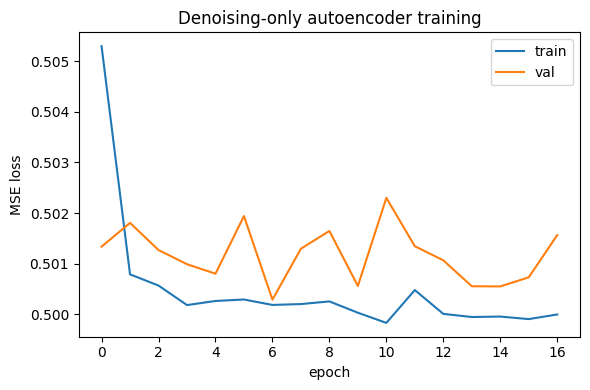

In [4]:
# Cell 4 — full training, denoising-only (SOI+noise, no interference)
def train_mitigation_ae(model, X_train, Y_train, X_val, Y_val, device,
                          epochs=100, batch_size=64, lr=3e-5, patience=10, seed=42):
    torch.manual_seed(seed)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    Xt = torch.tensor(X_train, device=device)
    Yt = torch.tensor(Y_train, device=device)
    Xv = torch.tensor(X_val, device=device)
    Yv = torch.tensor(Y_val, device=device)

    history = {"train_loss": [], "val_loss": []}
    best_val, best_state, patience_ct = float("inf"), None, 0
    n = Xt.shape[0]

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        ep_losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            out = model(Xt[idx])
            loss = loss_fn(out, Yt[idx])
            loss.backward(); opt.step()
            ep_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), Yv).item()

        train_loss = float(np.mean(ep_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}")

        if val_loss < best_val:
            best_val, best_state, patience_ct = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ct += 1
            if patience_ct >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_state)
    return model, history

model_denoise = MitigationAutoencoder(n_stages=2, n_hidden=32)
model_denoise, history_denoise = train_mitigation_ae(model_denoise, X_train, Y_train, X_val, Y_val, device)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history_denoise["train_loss"], label="train")
plt.plot(history_denoise["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend()
plt.title("Denoising-only autoencoder training")
plt.tight_layout()
plt.savefig("figures/mitigation_ae_denoise_only_training.png", dpi=150)
plt.show()

import os
os.makedirs("checkpoints", exist_ok=True)
torch.save(model_denoise.state_dict(), "checkpoints/mitigation_ae_denoise_only.pt")

Eb/N0=0dB  interference=0.3375  mitigated=0.5003  clean=0.1554  theoretical=0.0786
Eb/N0=1dB  interference=0.3199  mitigated=0.5059  clean=0.1321  theoretical=0.0563
Eb/N0=2dB  interference=0.3230  mitigated=0.5027  clean=0.1045  theoretical=0.0375
Eb/N0=3dB  interference=0.3229  mitigated=0.5087  clean=0.0813  theoretical=0.0229
Eb/N0=4dB  interference=0.3177  mitigated=0.5072  clean=0.0577  theoretical=0.0125
Eb/N0=5dB  interference=0.3197  mitigated=0.5027  clean=0.0391  theoretical=0.0060
Eb/N0=6dB  interference=0.3095  mitigated=0.5092  clean=0.0237  theoretical=0.0024


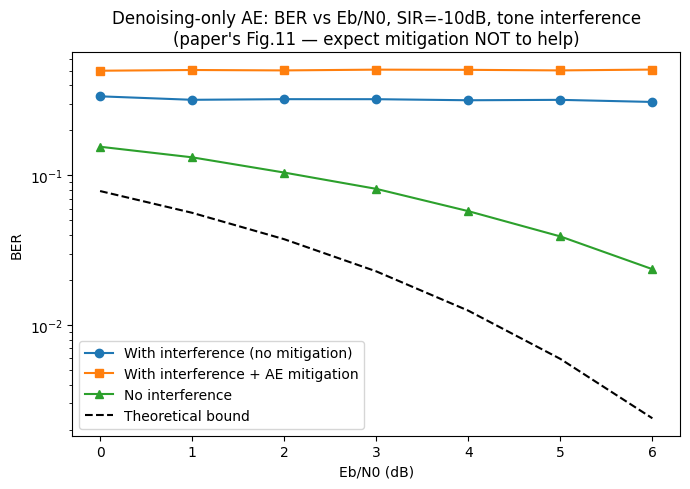

In [7]:
# Cell 5 — BER test: does DENOISING-ONLY autoencoder reduce BER against tone interference? (Fig.11/12)
from src.channel import mix_signal
from src.evaluate import matched_filter_ber, theoretical_ber

def ae_denoise(x_complex, model, device):
    channels = complex_to_channels(x_complex).astype(np.float32)
    with torch.no_grad():
        inp = torch.tensor(channels, device=device).unsqueeze(0)
        out = model(inp).squeeze(0).cpu().numpy()
    return out[0] + 1j*out[1]

SIR_DB_TEST = -10.0  # BASE-PAPER FACT (Fig.11 uses SIR=-10dB)
EBN0_RANGE = [0, 1, 2, 3, 4, 5, 6]  # BASE-PAPER FACT (Fig.11's x-axis range)
N_TRIALS = 300

ber_results = []
for ebn0_db in EBN0_RANGE:
    snr_db = ebn0_db - 10*np.log10(cfg.NSPS)  # invert our OUR ASSUMPTION Eb/N0<->SNR relationship

    ber_interference, ber_mitigated, ber_clean = [], [], []
    for _ in range(N_TRIALS):
        d = mix_signal(cfg, N_SYMBOLS, rng, interference_type="tone", contamination=1.0,
                        sir_db_range=(SIR_DB_TEST, SIR_DB_TEST), snr_db_range=(snr_db, snr_db),
                        apply_shift=False)
        x, bits, fd, phi_m, k_shift = d["x"], d["bits"], d["fd"], d["phi_m"], d["k_shift"]

        ber_interference.append(matched_filter_ber(x, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))

        x_mitigated = ae_denoise(x, model_denoise, device)
        ber_mitigated.append(matched_filter_ber(x_mitigated, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))

        d_clean = mix_signal(cfg, N_SYMBOLS, rng, interference_type="tone", contamination=0.0,
                              snr_db_range=(snr_db, snr_db), apply_shift=False)
        ber_clean.append(matched_filter_ber(d_clean["x"], d_clean["bits"], cfg, N_SYMBOLS,
                                              d_clean["fd"], d_clean["phi_m"], d_clean["k_shift"]))

    ber_results.append({
        "ebn0_db": ebn0_db,
        "ber_with_interference": np.mean(ber_interference),
        "ber_mitigated": np.mean(ber_mitigated),
        "ber_no_interference": np.mean(ber_clean),
        "ber_theoretical": theoretical_ber(ebn0_db),
    })
    print(f"Eb/N0={ebn0_db}dB  interference={np.mean(ber_interference):.4f}  "
          f"mitigated={np.mean(ber_mitigated):.4f}  clean={np.mean(ber_clean):.4f}  "
          f"theoretical={theoretical_ber(ebn0_db):.4f}")

import pandas as pd
ber_df = pd.DataFrame(ber_results)
ber_df.to_csv("results/step8_denoise_only_ber.csv", index=False)

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_with_interference"], marker='o', label="With interference (no mitigation)")
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_mitigated"], marker='s', label="With interference + AE mitigation")
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_no_interference"], marker='^', label="No interference")
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_theoretical"], linestyle='--', color='black', label="Theoretical bound")
plt.xlabel("Eb/N0 (dB)"); plt.ylabel("BER")
plt.title("Denoising-only AE: BER vs Eb/N0, SIR=-10dB, tone interference\n(paper's Fig.11 — expect mitigation NOT to help)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/step8_denoise_only_ber.png", dpi=150)
plt.show()